# **Insurance Cost Analysis**


In this project, I performed analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 

 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 
 


For this project, I used the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


#### Importing Required Libraries


In [8]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

#### Importing the dataset

In [2]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
df = pd.read_csv(filepath, header=None)
df.head(10)

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


Adding the headers to the dataframe 


In [3]:
headers= ["age", 'gender', 'BMI', 'no_of_children', 'smoker', 'region', 'charges']
df.columns= headers
df.head()

,age,gender,BMI,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


Replacing the '?' entries with 'NaN' values.

In [4]:
df.replace("?", np.nan, inplace=True)

---
<div class="alert alert-block alert-warning">

## Data Wrangling
</div>


Using `dataframe.info()` to identify the columns that have some `Null` information.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   BMI             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


Handling missing data:

- For continuous attributes (e.g., age), replacing missing values with the mean.
- For categorical attributes (e.g., smoker), replacing missing values with the most frequent value.


In [9]:
avg_age= df["age"].astype(float).mean().round(2)
df["age"].replace(np.nan, avg_age, inplace=True)

freq_smoker= df["smoker"].value_counts().idxmax()
df["smoker"].replace(np.nan, freq_smoker, inplace=True)

df["age"]= df["age"].astype(float)
df["smoker"]= df["smoker"].astype(int)

df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   float64
 1   gender          2772 non-null   int64  
 2   BMI             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 151.7 KB


Updating the `charges` column such that all values are rounded to nearest 2 decimal places.

In [10]:
df["charges"]= df["charges"].round(2)
df["age"]= df["age"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   BMI             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


---
<div class="alert alert-block alert-warning">

## Exploratory Data Analysis
</div>

Implementing the regression plot for `charges` with respect to `bmi`. 


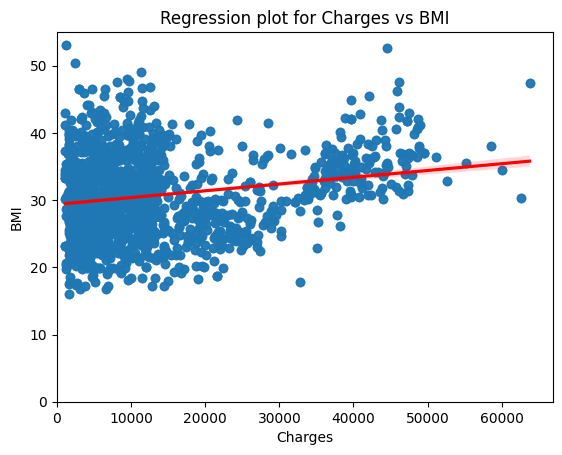

In [11]:
sns.regplot(x= df["charges"], y= df["BMI"], line_kws={"color": "red"})
plt.ylim(0,)
plt.xlim(0,)
plt.xlabel("Charges")
plt.ylabel("BMI")
plt.title("Regression plot for Charges vs BMI")
plt.show();

Creating the box plot for `charges` with respect to `smoker`.


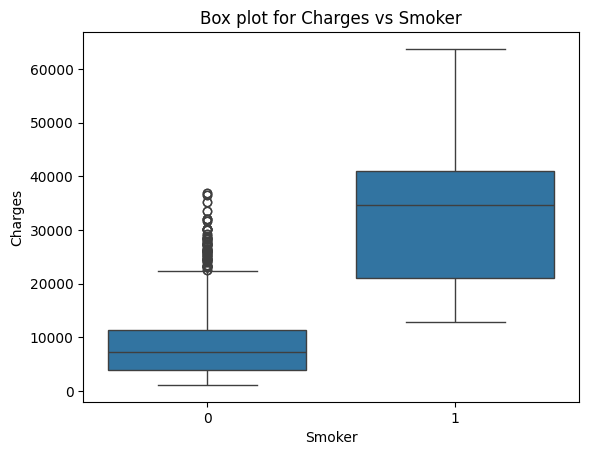

In [12]:
sns.boxplot(x=df["smoker"],y=df["charges"])
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.title("Box plot for Charges vs Smoker")
plt.show(); 

Printing the correlation matrix for the dataset.


In [13]:
df.corr()

,age,gender,BMI,no_of_children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
gender,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
BMI,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


---
<div class="alert alert-block alert-warning">

## Model Development
</div>

Fiting a linear regression model used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Printing the $ R^2 $ score of this model.


In [14]:
lr= LinearRegression()
x_data= df[["smoker"]]
y_data= df["charges"]
lr.fit(x_data, y_data)
round(lr.score(x_data, y_data), 3)

0.622

Fiting a linear regression model used to predict the `charges` value, just by using all other attributes of the dataset. Printing the $ R^2 $ score of this model. I can see an improvement in the performance.


In [15]:
Z = df[["age", "gender", "BMI", "no_of_children", "smoker", "region"]]
lr.fit(Z,y_data)
round(lr.score(Z, y_data), 3)

0.75

Creating a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There is even further improvement in the performance.


In [16]:
Input= [("scale", StandardScaler()), ("polynomial", PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe= Pipeline(Input)
Z= Z.astype(float)
pipe.fit(Z, y_data)
ypipe= pipe.predict(Z)
round(r2_score(y_data, ypipe), 3)

0.845

---
<div class="alert alert-block alert-warning">

## Model Refinement
</div>

Spliting the data into training and testing subsets with 20%.


In [17]:
x_train, x_test, y_train, y_test= train_test_split(Z, y_data, test_size=0.20, random_state=1)

Initializing a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fiting the model using training data data subset. Printing the $ R^2 $ score for the testing data.


In [ ]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
Y_hat= RidgeModel.predict(x_test)
round(r2_score(y_test, Y_hat), 3)

0.6760807731582404


Appling polynomial transformation to the training parameters with degree=2. Used this transformed feature set to fit the same regression model, as above, using the training subset. Printing the $ R^2 $ score for the testing subset.


In [19]:
poly= PolynomialFeatures(degree=2)
x_train_pr= poly.fit_transform(x_train)
x_test_pr= poly.fit_transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
Y_hat= RidgeModel.predict(x_test_pr)
round(r2_score(y_test, Y_hat), 3)

0.784

---
<div class="alert alert-block alert-info">

### Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)

</div>